<a href="https://colab.research.google.com/github/Devv07/ai-ml-practice/blob/ai-ml-practice/Search_Algorithm(3).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [19]:
import heapq
from collections import deque
import matplotlib.pyplot as plt
import networkx as nx
import time
from sklearn.linear_model import LinearRegression
import numpy as np

**Breadth First Search**

A is the start state( initial board layout) and F is the goal state

       A
     /   \
    B     C
    |   / | \
    D  B  D  E
       |     |
       D     F


In [2]:
def bfs(graph, start):
    visited = set()
    queue = deque([start])
    visited.add(start)

    while queue:
        node = queue.popleft()
        print(node, end=" ")

        for neighbor in graph[node]:
            if neighbor not in visited:
                visited.add(neighbor)
                queue.append(neighbor)

In [3]:
# Graph
graph = {
    'A': ['B', 'C'],
    'B': ['D'],
    'C': ['B','D','E'],
    'D': [],
    'E': ['F'],
    'F': []
}

bfs(graph, 'A')

A B C D E F 

**Depth First Search**

Depth First Search (DFS) is a graph traversal algorithm that explores a graph by going as deep as possible along one path before backtracking.

       A
     /   \
    B     C
    |   / | \
    D  B  D  E
       |     |
       D     F


In [4]:
def dfs(graph, node, visited=set()):
    if node not in visited:
        print(node, end=" ")
        visited.add(node)
        for neighbor in graph[node]:
            dfs(graph, neighbor, visited)

In [5]:
# Graph
graph = {
    'A': ['B', 'C'],
    'B': ['D'],
    'C': ['B','D','E'],
    'D': [],
    'E': ['F'],
    'F': []
}

dfs(graph, 'A')

A B D C E F 

**Greedy Best First Search**

Greedy Best-First Search is an informed search algorithm that always expands the node that looks closest to the goal according to a heuristic function.

      A(6)
     /   \
  B(4)   C(2)
  |       |
  D(3)    G(0)

In [6]:

def greedy_best_first(graph, heuristic, start, goal):
    visited = set()
    pq = [(heuristic[start], start)]

    while pq:
        h, node = heapq.heappop(pq)
        print(node, end=" ")

        if node == goal:
            print("\nGoal found!")
            return

        visited.add(node)

        for neighbor in graph[node]:
            if neighbor not in visited:
                heapq.heappush(pq, (heuristic[neighbor], neighbor))

    print("\nGoal not found")


In [7]:
graph = {
    'A': ['B', 'C'],
    'B': ['D'],
    'C': ['G'],
    'D': [],
    'G': []
}

heuristic = {
    'A': 6,
    'B': 4,
    'C': 2,
    'D': 3,
    'G': 0
}

greedy_best_first(graph, heuristic, 'A', 'G')

A C G 
Goal found!


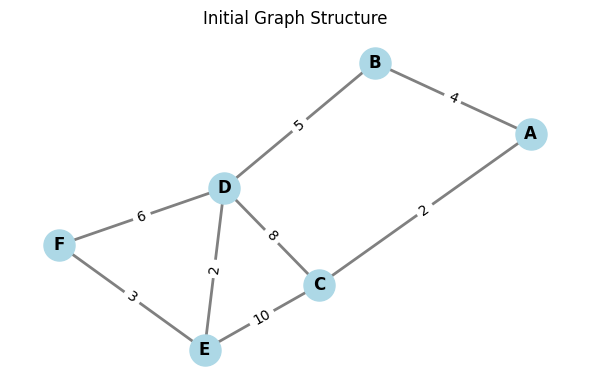

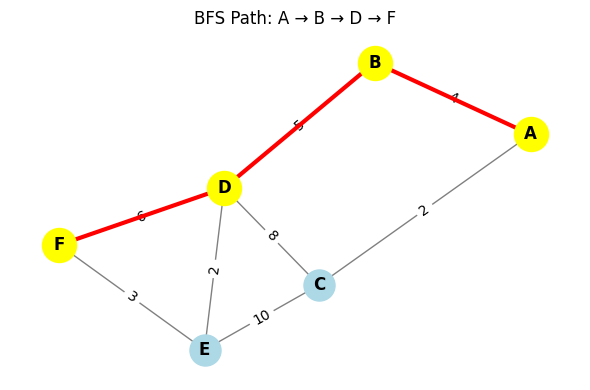

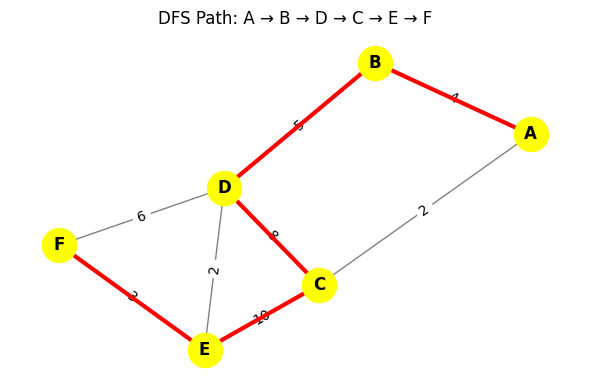

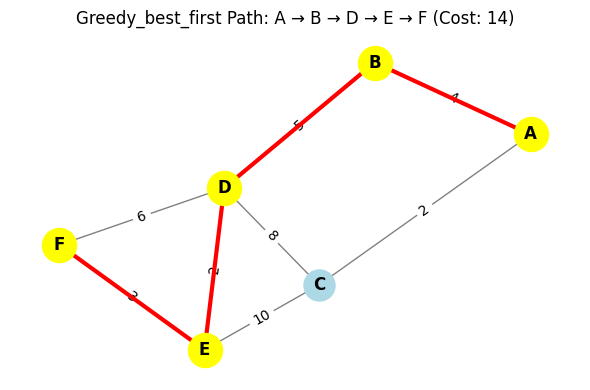


BFS Path (Shortest Steps):
  Path: A → B → D → F
  Number of steps: 3

DFS Path (Depth First):
  Path: A → B → D → C → E → F
  Number of steps: 5

Greedy Best First Path (Lowest Cost):
  Path: A → B → D → E → F
  Total cost: 14
BFS Path Cost: 15
DFS Path Cost: 30
Greedy_best_first Path Cost: 14


In [13]:
# Add graph algorithms demo including BFS, DFS, and greedy_best_first with visuals


class GraphVisualizer:
    def __init__(self):
        self.G = nx.Graph()
        self.pos = None

    def create_graph(self, edges):
        self.G.clear()
        for u, v, cost in edges:
            self.G.add_edge(u, v, weight=cost)
        self.pos = nx.spring_layout(self.G, seed=42)

    def plot_initial_graph(self):
        plt.figure(figsize=(6, 4), num="Initial Graph")

        nx.draw_networkx_nodes(self.G, self.pos, node_size=500,
                              node_color='lightblue')
        nx.draw_networkx_labels(self.G, self.pos, font_size=12,
                               font_weight='bold')
        nx.draw_networkx_edges(self.G, self.pos, edge_color='gray',
                              width=2)

        edge_labels = nx.get_edge_attributes(self.G, 'weight')
        nx.draw_networkx_edge_labels(self.G, self.pos,
                                    edge_labels=edge_labels)

        plt.title("Initial Graph Structure")
        plt.axis('off')
        plt.tight_layout()
        plt.show()

    def plot_algorithm(self, path, title):
        plt.figure(figsize=(6, 4))

        nx.draw_networkx_nodes(self.G, self.pos, node_size=500,
                              node_color='lightblue')
        nx.draw_networkx_labels(self.G, self.pos, font_size=12,
                               font_weight='bold')
        nx.draw_networkx_edges(self.G, self.pos, edge_color='gray',
                              width=1)

        edge_labels = nx.get_edge_attributes(self.G, 'weight')
        nx.draw_networkx_edge_labels(self.G, self.pos,
                                    edge_labels=edge_labels)

        path_edges = [(path[i], path[i+1]) for i in range(len(path)-1)]
        nx.draw_networkx_edges(self.G, self.pos, edgelist=path_edges,
                              edge_color='red', width=3)
        nx.draw_networkx_nodes(self.G, self.pos, nodelist=path,
                              node_size=600, node_color='yellow')

        plt.title(title)
        plt.axis('off')
        plt.tight_layout()
        plt.show()

class GraphAlgorithms:
    def __init__(self, edges):
        self.graph = {}
        for u, v, cost in edges:
            self.add_edge(u, v, cost)
        self.visualizer = GraphVisualizer()
        self.visualizer.create_graph(edges)

    def add_edge(self, u, v, cost=1):
        if u not in self.graph:
            self.graph[u] = []
        if v not in self.graph:
            self.graph[v] = []
        self.graph[u].append((v, cost))
        self.graph[v].append((u, cost))

    def bfs(self, start, target):
        visited = set()
        queue = deque([[start]])
        visited.add(start)

        while queue:
            path = queue.popleft()
            node = path[-1]

            if node == target:
                self.visualizer.plot_algorithm(path,
                    f"BFS Path: {' → '.join(path)}")
                return path

            for neighbor, _ in self.graph.get(node, []):
                if neighbor not in visited:
                    visited.add(neighbor)
                    new_path = list(path)
                    new_path.append(neighbor)
                    queue.append(new_path)

        return None

    def dfs(self, start, target):
        visited = set()
        stack = [[start]]

        while stack:
            path = stack.pop()
            node = path[-1]

            if node in visited:
                continue

            visited.add(node)

            if node == target:
                self.visualizer.plot_algorithm(path,
                    f"DFS Path: {' → '.join(path)}")
                return path

            neighbors = sorted(self.graph.get(node, []), reverse=True)
            for neighbor, _ in neighbors:
                if neighbor not in visited:
                    new_path = list(path)
                    new_path.append(neighbor)
                    stack.append(new_path)

        return None

    def greedy_best_first(self, start, target):
        distances = {node: float('inf') for node in self.graph}
        distances[start] = 0
        pq = [(0, start, [start])]
        visited = set()

        while pq:
            current_dist, current, path = heapq.heappop(pq)

            if current in visited:
                continue

            visited.add(current)

            if current == target:
                self.visualizer.plot_algorithm(path,
                    f"Greedy_best_first Path: {' → '.join(path)} (Cost: {current_dist})")
                return path, current_dist

            for neighbor, cost in self.graph.get(current, []):
                if neighbor not in visited:
                    new_dist = current_dist + cost
                    if new_dist < distances[neighbor]:
                        distances[neighbor] = new_dist
                        new_path = path + [neighbor]
                        heapq.heappush(pq, (new_dist, neighbor, new_path))

        return None, float('inf')

edges = [
    ('A', 'B', 4), ('A', 'C', 2),
    ('B', 'D', 5), ('C', 'D', 8),
    ('C', 'E', 10), ('D', 'F', 6),
    ('E', 'F', 3), ('D', 'E', 2)
]

algo = GraphAlgorithms(edges)

algo.visualizer.plot_initial_graph()

bfs_path = algo.bfs('A', 'F')
dfs_path = algo.dfs('A', 'F')
greedy_best_first_path, greedy_best_first_cost = algo.greedy_best_first('A', 'F')

print(f"\nBFS Path (Shortest Steps):")
print(f"  Path: {' → '.join(bfs_path)}")
print(f"  Number of steps: {len(bfs_path)-1}")

print(f"\nDFS Path (Depth First):")
print(f"  Path: {' → '.join(dfs_path)}")
print(f"  Number of steps: {len(dfs_path)-1}")

print(f"\nGreedy Best First Path (Lowest Cost):")
print(f"  Path: {' → '.join(greedy_best_first_path)}")
print(f"  Total cost: {greedy_best_first_cost}")

path_costs = {
    'BFS': sum([cost for u,v,cost in edges
                if (u,v) in zip(bfs_path, bfs_path[1:]) or
                   (v,u) in zip(bfs_path, bfs_path[1:])]),
    'DFS': sum([cost for u,v,cost in edges
                if (u,v) in zip(dfs_path, dfs_path[1:]) or
                   (v,u) in zip(dfs_path, dfs_path[1:])]),
    'greedy_best_first': greedy_best_first_cost
}

print(f"BFS Path Cost: {path_costs['BFS']}")
print(f"DFS Path Cost: {path_costs['DFS']}")
print(f"Greedy_best_first Path Cost: {path_costs['greedy_best_first']}")

**Linear Search Algorithm**

Linear Search is the simplest searching algorithm.
It checks each element one by one until the target value is found or the list ends.

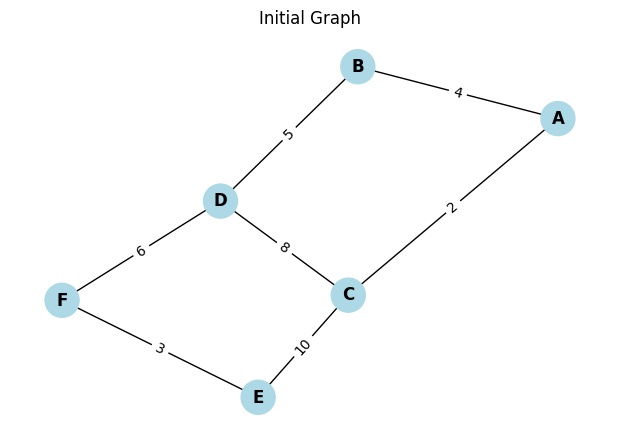

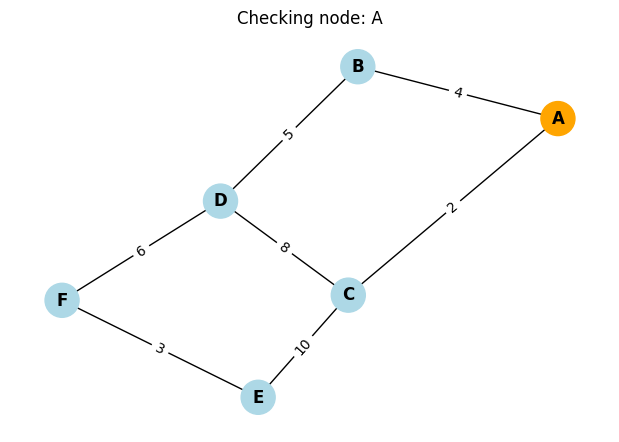

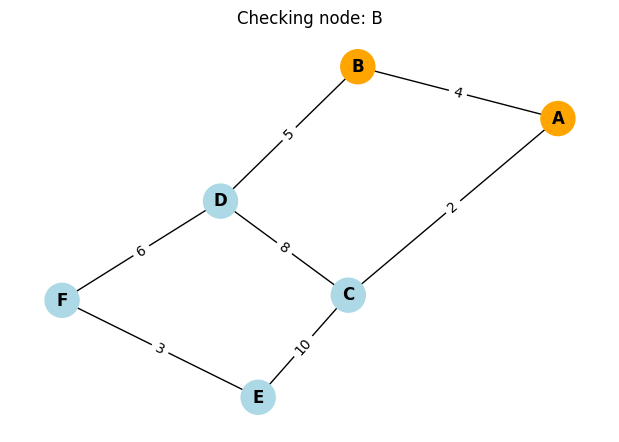

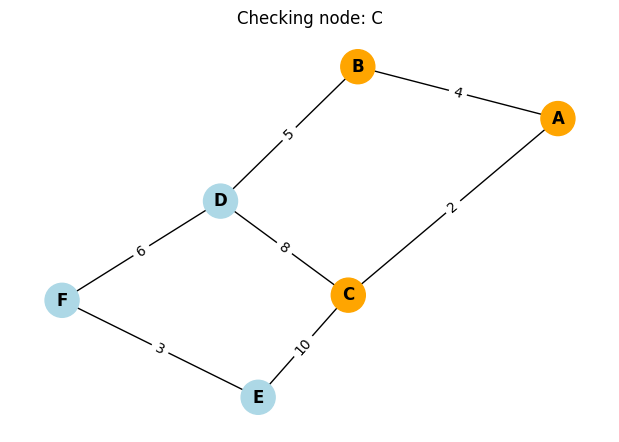

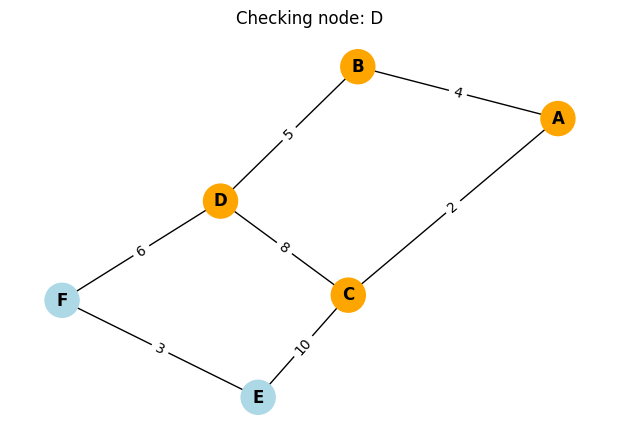

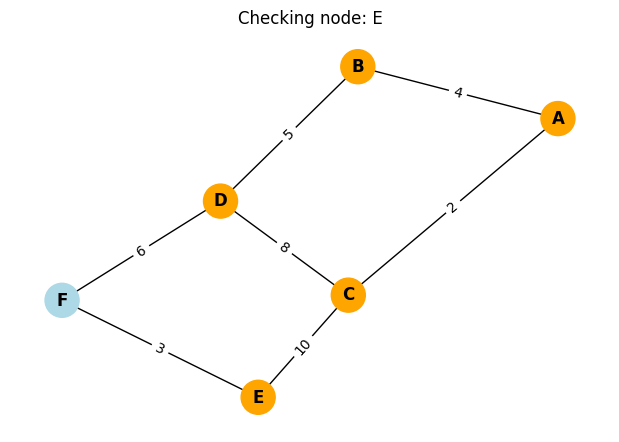

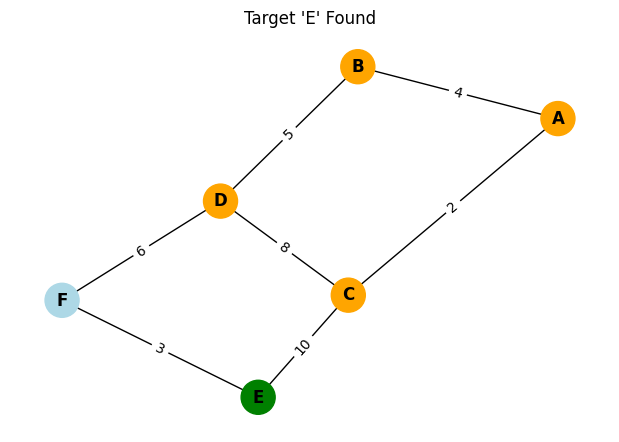

Result: E


In [16]:

class LinearSearchGraph:
    def __init__(self, edges):
        self.G = nx.Graph()
        for u, v, w in edges:
            self.G.add_edge(u, v, weight=w)
        self.pos = nx.spring_layout(self.G, seed=42)

    def plot_graph(self, visited=None, found=None, title="Linear Search on Graph"):
        plt.figure(figsize=(6, 4))

        node_colors = []
        for node in self.G.nodes():
            if found and node == found:
                node_colors.append("green")      # found node
            elif visited and node in visited:
                node_colors.append("orange")     # visited nodes
            else:
                node_colors.append("lightblue")  # unvisited

        nx.draw(self.G, self.pos,
                with_labels=True,
                node_color=node_colors,
                node_size=600,
                font_weight="bold")

        edge_labels = nx.get_edge_attributes(self.G, "weight")
        nx.draw_networkx_edge_labels(self.G, self.pos, edge_labels=edge_labels)

        plt.title(title)
        plt.axis("off")
        plt.show()

    def linear_search(self, target):
        visited = []
        nodes = list(self.G.nodes())

        for node in nodes:
            visited.append(node)
            self.plot_graph(visited=visited, title=f"Checking node: {node}")
            time.sleep(0.8)

            if node == target:
                self.plot_graph(visited=visited, found=node,
                                title=f"Target '{target}' Found")
                return node

        return None

edges = [
    ('A', 'B', 4), ('A', 'C', 2),
    ('B', 'D', 5), ('C', 'D', 8),
    ('C', 'E', 10), ('D', 'F', 6),
    ('E', 'F', 3)
]

ls = LinearSearchGraph(edges)

ls.plot_graph(title="Initial Graph")
result = ls.linear_search('E')

print("Result:", result)


**Linear Regression**

Linear Regression is a supervised machine learning algorithm used to find the relationship between two variables by fitting a straight line.

Formula: y = 5.90 + 5.17*x


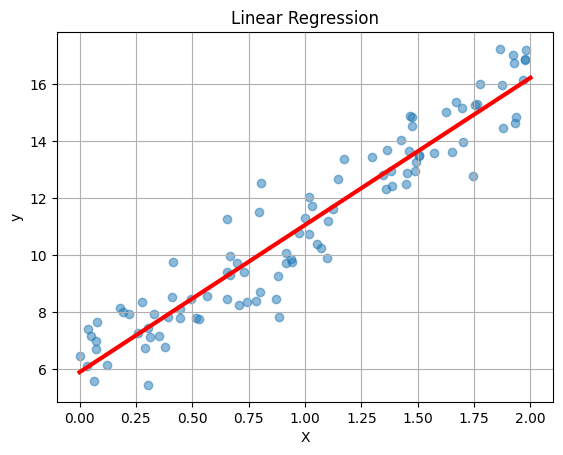

Prediction for x=1.5: 13.65


In [23]:
np.random.seed(56)
X = 2 * np.random.rand(100, 1)
y = 6 + 5 * X + np.random.randn(100, 1)

model = LinearRegression()
model.fit(X, y)

print(f"Formula: y = {model.intercept_[0]:.2f} + {model.coef_[0][0]:.2f}*x")

X_new = np.array([[0], [2]])
y_pred = model.predict(X_new)

plt.scatter(X, y, alpha=0.5)
plt.plot(X_new, y_pred, 'r-', linewidth=3)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression')
plt.grid(True)
plt.show()

test_value = np.array([[1.5]])
prediction = model.predict(test_value)
print(f"Prediction for x={test_value[0][0]}: {prediction[0][0]:.2f}")